In [135]:
import os
import shutil
from pathlib import Path
import pandas as pd
import shutil
import random

import sys
from PIL import Image
import torch
import torchvision
import timm
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import cohen_kappa_score
from collections import Counter
import torch.nn.functional as F
import torch.optim as optim

import torch.nn as nn


print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/myenv/bin/python


In [136]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
GPU: NVIDIA RTX A4000


In [141]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16 # CHANGED FROM 32
NUM_CLASSES = 5
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DATA_DIR = Path("/kaggle/working/SplitDATA") / "data"
DATA_DIR = Path("SplitDATA") / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_NAME = "deit_small_distilled_patch16_224"
MODEL_NAME_BASELINE = "deit_small_patch16_224"

TEACHER_NAME = "regnety_160"

NUM_EPOCHS = 12
TEACHER_EPOCHS = 12
LEARNING_RATE = 5e-5 #1e-4
ALPHA = 0.2
#ALPHA = 0.3
TAU = 2.0
# LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
# ALPHA = 0.5
# TAU = 1.0
PATIENCE = 8 #5


In [ ]:
class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(NUM_CLASSES):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


# train_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(15),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop( # add on exp 7
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.15
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = DRDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DRDataset(VAL_DIR, transform=val_test_transform)
test_dataset = DRDataset(TEST_DIR, transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")



class_counts = Counter(train_dataset.labels)
print("Class counts:", class_counts)


class_weights = None

print("Class weights disabled to prevent severe-class overprediction.")

from torch.utils.data import WeightedRandomSampler
from collections import Counter



sample_weights = [ # exp 8
    1.0 / class_counts[label]
    for label in train_dataset.labels
]

sampler = WeightedRandomSampler( #exp 8
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    #shuffle=True,
    sampler=sampler,#exp 8
    shuffle=False, #exp 8
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nData loaders ready!")

Train dataset: 21074 images
Val dataset:   7026 images
Test dataset:  7026 images
Class counts: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Class weights disabled to prevent severe-class overprediction.

Data loaders ready!


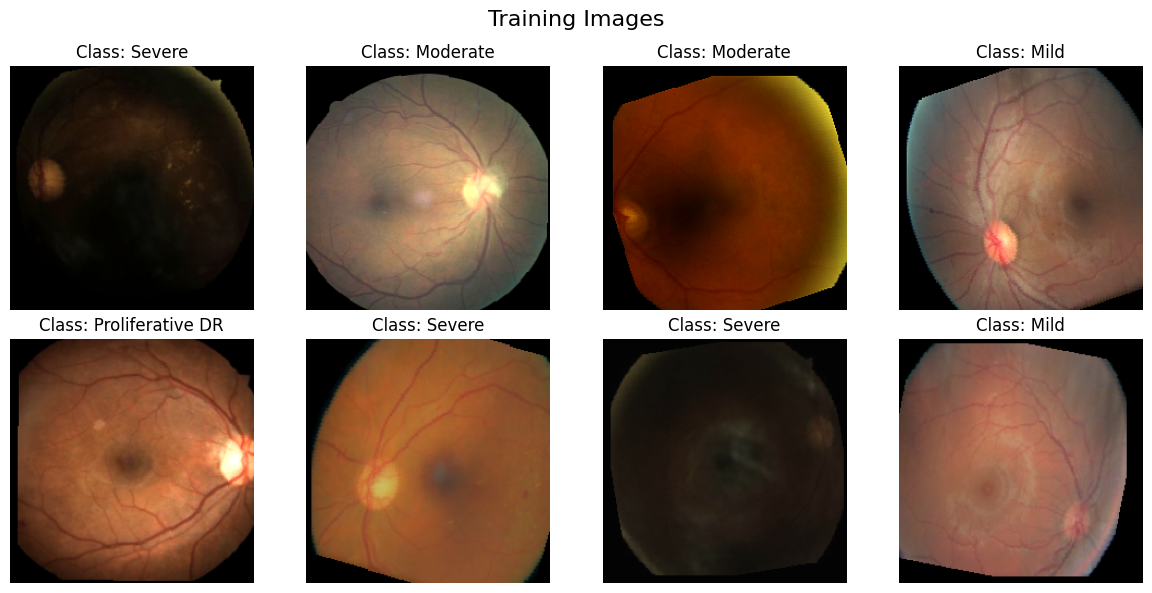

In [143]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [144]:
# creating FULL DeiT student model
student_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f"Student model: {MODEL_NAME}")
print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")

Student model: deit_small_distilled_patch16_224
Total params: 21.67M
Trainable params: 21.67M


In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, cohen_kappa_score

os.makedirs("SplitDATA/checkpoints", exist_ok=True)
os.makedirs("SplitDATA/logs", exist_ok=True)

teacher_ckpt = "SplitDATA/checkpoints/teacher_regnety160_best.pth"
teacher_log_path = "SplitDATA/logs/teacher_training_log.txt"

teacher_model = timm.create_model(
    TEACHER_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

# criterion_teacher = nn.CrossEntropyLoss(
    # #weight=class_weights, 
    # label_smoothing=0.05 
# )

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()


def train_teacher_if_needed(model, train_loader, val_loader, ckpt_path, epochs=TEACHER_EPOCHS):

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print("Loaded existing teacher checkpoint")
        return model

    criterion_teacher = FocalLoss(
        gamma=2.0,
        label_smoothing=0.05
    )

    optimizer_teacher = optim.AdamW(
        model.parameters(),
        lr=5e-5,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_teacher = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_teacher,
        T_max=epochs,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=torch.cuda.is_available()
    )

    best_val_qwk = -1.0
    best_val_f1 = -1.0

    with open(teacher_log_path, "w") as f:
        f.write("====================================================\n")
        f.write("Teacher Training Log - RegNetY-160\n")
        f.write("====================================================\n\n")
        f.write(f"Teacher Model: {TEACHER_NAME}\n")
        f.write(f"Epochs: {epochs}\n")
        f.write("Loss: FocalLoss(gamma=2.0, label_smoothing=0.05)\n")
        f.write("Optimizer: AdamW\n")
        f.write("Learning Rate: 5e-5\n")
        f.write(f"Weight Decay: {WEIGHT_DECAY}\n\n")

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        train_preds, train_labels = [], []

        for images, labels in tqdm(
            train_loader,
            desc=f"Teacher Train {epoch+1}/{epochs}",
            leave=False
        ):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_teacher.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer_teacher)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer_teacher)
            scaler.update()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            train_preds.extend(preds.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(
            train_labels,
            train_preds,
            average="macro",
            zero_division=0
        )

        model.eval()

        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():

            for images, labels in tqdm(
                val_loader,
                desc=f"Teacher Val {epoch+1}/{epochs}",
                leave=False
            ):

                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)

        val_acc = accuracy_score(val_labels, val_preds)

        val_bal_acc = balanced_accuracy_score(
            val_labels,
            val_preds
        )

        val_f1 = f1_score(
            val_labels,
            val_preds,
            average="macro",
            zero_division=0
        )

        val_qwk = cohen_kappa_score(
            val_labels,
            val_preds,
            weights="quadratic"
        )

        scheduler_teacher.step()

        epoch_log = (
            f"\n====================================================\n"
            f"Teacher Epoch {epoch+1}/{epochs}\n"
            f"====================================================\n"
            f"Train Loss          : {train_loss:.4f}\n"
            f"Train Accuracy      : {train_acc*100:.2f}%\n"
            f"Train Macro-F1      : {train_f1:.4f}\n\n"
            f"Val Loss            : {val_loss:.4f}\n"
            f"Val Accuracy        : {val_acc*100:.2f}%\n"
            f"Val Balanced Acc    : {val_bal_acc:.4f}\n"
            f"Val Macro-F1        : {val_f1:.4f}\n"
            f"Val QWK             : {val_qwk:.4f}\n"
        )

        print(epoch_log)

        with open(teacher_log_path, "a") as f:
            f.write(epoch_log)

        if val_qwk > best_val_qwk:

            best_val_qwk = val_qwk
            best_val_f1 = val_f1

            torch.save(model.state_dict(), ckpt_path)

            msg = (
                f"\nBest teacher saved\n"
                f"Best Val QWK      : {best_val_qwk:.4f}\n"
                f"Val Macro-F1      : {best_val_f1:.4f}\n"
            )

            print(msg)

            with open(teacher_log_path, "a") as f:
                f.write(msg)

    model.load_state_dict(
        torch.load(
            ckpt_path,
            map_location=DEVICE
        )
    )

    final_msg = (
        f"\nTeacher ready\n"
        f"Best Val QWK      : {best_val_qwk:.4f}\n"
        f"Best Val Macro-F1 : {best_val_f1:.4f}\n"
    )

    print(final_msg)

    with open(teacher_log_path, "a") as f:
        f.write(final_msg)

    return model


teacher_model = train_teacher_if_needed(
    teacher_model,
    train_loader,
    val_loader,
    teacher_ckpt,
    epochs=TEACHER_EPOCHS
)

teacher_model.eval()

for p in teacher_model.parameters():
    p.requires_grad = False

print("Teacher loaded and frozen for distillation.")


Teacher Epoch 1/12
Train Loss          : 0.6982
Train Accuracy      : 46.79%
Train Macro-F1      : 0.4667

Val Loss            : 0.4689
Val Accuracy        : 73.85%
Val Balanced Acc    : 0.4774
Val Macro-F1        : 0.4368
Val QWK             : 0.5370


Best teacher saved
Best Val QWK      : 0.5370
Val Macro-F1      : 0.4368




Teacher Epoch 2/12
Train Loss          : 0.5339
Train Accuracy      : 57.12%
Train Macro-F1      : 0.5696

Val Loss            : 0.4927
Val Accuracy        : 65.31%
Val Balanced Acc    : 0.4907
Val Macro-F1        : 0.4598
Val QWK             : 0.5570


Best teacher saved
Best Val QWK      : 0.5570
Val Macro-F1      : 0.4598




Teacher Epoch 3/12
Train Loss          : 0.4317
Train Accuracy      : 63.86%
Train Macro-F1      : 0.6402

Val Loss            : 0.5164
Val Accuracy        : 60.73%
Val Balanced Acc    : 0.4753
Val Macro-F1        : 0.4274
Val QWK             : 0.5167




Teacher Epoch 4/12
Train Loss          : 0.3592
Train Accuracy      : 69.31%
Train Macro-F1      : 0.6906

Val Loss            : 0.6321
Val Accuracy        : 46.04%
Val Balanced Acc    : 0.4831
Val Macro-F1        : 0.4021
Val QWK             : 0.4300




Teacher Epoch 5/12
Train Loss          : 0.3072
Train Accuracy      : 73.77%
Train Macro-F1      : 0.7400

Val Loss            : 0.4318
Val Accuracy        : 74.38%
Val Balanced Acc    : 0.4918
Val Macro-F1        : 0.4798
Val QWK             : 0.6370


Best teacher saved
Best Val QWK      : 0.6370
Val Macro-F1      : 0.4798



...


Teacher Epoch 10/12
Train Loss          : 0.1161
Train Accuracy      : 91.11%
Train Macro-F1      : 0.9112

Val Loss            : 0.5492
Val Accuracy        : 69.60%
Val Balanced Acc    : 0.4875
Val Macro-F1        : 0.4937
Val QWK             : 0.6118




Teacher Epoch 11/12
Train Loss          : 0.0970
Train Accuracy      : 92.84%
Train Macro-F1      : 0.9286

Val Loss            : 0.5217
Val Accuracy        : 72.36%
Val Balanced Acc    : 0.4824
Val Macro-F1        : 0.4959
Val QWK             : 0.6362




Teacher Epoch 12/12
Train Loss          : 0.0827
Train Accuracy      : 93.94%
Train Macro-F1      : 0.9392

Val Loss            : 0.5481
Val Accuracy        : 71.63%
Val Balanced Acc    : 0.4854
Val Macro-F1        : 0.5019
Val QWK             : 0.6374


Best teacher saved
Best Val QWK      : 0.6374
Val Macro-F1      : 0.5019



/tmp/ipykernel_617293/1371526759.py:219: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Teacher ready
Best Val QWK      : 0.6374
Best Val Macro-F1 : 0.5019

Teacher loaded and frozen for distillation.


In [ ]:

import torch.optim as optim
# Distillation training setup
# criterion_cls = nn.CrossEntropyLoss(
#     #weight=class_weights,
#     label_smoothing=0.05
# )


class FocalLoss(nn.Module): #exp 7
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()


# Classification loss for hard labels
criterion_cls = FocalLoss(
    gamma=2.0,
    label_smoothing=0.05
)

# KL divergence loss for soft teacher-student distillation
criterion_dist = nn.KLDivLoss(
    reduction="batchmean"
)

optimizer = optim.AdamW(
    student_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print("Distillation training setup complete")
print(f"Classification Loss: FocalLoss(gamma=2.0, label_smoothing=0.05)")
print(f"Distillation Loss: KLDivLoss")
print(f"ALPHA = {ALPHA}, TAU = {TAU}")

Distillation training setup complete
Classification Loss: FocalLoss(gamma=2.0, label_smoothing=0.05)
Distillation Loss: KLDivLoss
ALPHA = 0.2, TAU = 2.0


In [ ]:

# DeiT WITHOUT DISTILLATION token/ Uses normal DeiT, no teacher

baseline_model = timm.create_model(
    MODEL_NAME_BASELINE,
    pretrained=True,
    num_classes=5
).to(DEVICE)

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=NUM_EPOCHS
)

baseline_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

best_baseline_qwk = -1.0
baseline_patience_counter = 0

baseline_log_path = "SplitDATA/logs/deit_without_distillation_log.txt"

with open(baseline_log_path, "w") as f:
    f.write("=====================================================\n")
    f.write("DeiT WITHOUT Distillation Training Log\n")
    f.write("=====================================================\n\n")
    f.write(f"Model: {MODEL_NAME_BASELINE}\n")
    f.write("Teacher Used: No\n")
    f.write("Loss: CrossEntropy only\n\n")

for epoch in range(1, NUM_EPOCHS + 1):

    baseline_model.train()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"No-Distill Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

        baseline_scaler.scale(loss).backward()

        baseline_scaler.unscale_(baseline_optimizer)
        torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), max_norm=1.0)

        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()
      
        train_loss += loss.item()

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    baseline_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"No-Distill Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

    baseline_scheduler.step()

    epoch_log = (
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"Train Loss          : {train_loss:.4f}\n"
        f"Train Accuracy      : {train_acc*100:.2f}%\n"
        f"Train Macro-F1      : {train_f1:.4f}\n"
        f"Validation Loss     : {val_loss:.4f}\n"
        f"Validation Accuracy : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc  : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1 : {val_f1:.4f}\n"
        f"Validation QWK      : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(baseline_log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_baseline_qwk:

        best_baseline_qwk = val_qwk
        baseline_patience_counter = 0

        torch.save(
            baseline_model.state_dict(),
            "SplitDATA/checkpoints/best_deit_without_distillation.pth"
        )

        msg = f"\nBest no-distillation DeiT saved | Val QWK: {val_qwk:.4f}\n"
        print(msg)

        with open(baseline_log_path, "a") as f:
            f.write(msg)

    else:

        baseline_patience_counter += 1

        if baseline_patience_counter >= PATIENCE:
            stop_msg = f"\nEarly stopping at epoch {epoch}\n"
            print(stop_msg)

            with open(baseline_log_path, "a") as f:
                f.write(stop_msg)

            break

print(f"DeiT without distillation complete | Best Val QWK: {best_baseline_qwk:.4f}")


Epoch 01/12
Train Loss          : 0.6389
Train Accuracy      : 50.87%
Train Macro-F1      : 0.5066
Validation Loss     : 0.5647
Validation Accuracy : 51.71%
Validation Bal Acc  : 0.4910
Validation Macro-F1 : 0.4037
Validation QWK      : 0.4648


Best no-distillation DeiT saved | Val QWK: 0.4648




Epoch 02/12
Train Loss          : 0.4493
Train Accuracy      : 63.58%
Train Macro-F1      : 0.6339
Validation Loss     : 0.5999
Validation Accuracy : 57.09%
Validation Bal Acc  : 0.4857
Validation Macro-F1 : 0.3961
Validation QWK      : 0.4183




Epoch 03/12
Train Loss          : 0.3539
Train Accuracy      : 69.82%
Train Macro-F1      : 0.6959
Validation Loss     : 0.5956
Validation Accuracy : 41.94%
Validation Bal Acc  : 0.4734
Validation Macro-F1 : 0.3930
Validation QWK      : 0.4146




Epoch 04/12
Train Loss          : 0.2923
Train Accuracy      : 75.30%
Train Macro-F1      : 0.7499
Validation Loss     : 0.5038
Validation Accuracy : 62.58%
Validation Bal Acc  : 0.4721
Validation Macro-F1 : 0.4289
Validation QWK      : 0.4809


Best no-distillation DeiT saved | Val QWK: 0.4809




Epoch 05/12
Train Loss          : 0.2428
Train Accuracy      : 79.86%
Train Macro-F1      : 0.7985
Validation Loss     : 0.5925
Validation Accuracy : 52.60%
Validation Bal Acc  : 0.4583
Validation Macro-F1 : 0.4145
Validation QWK      : 0.4198



...


Epoch 08/12
Train Loss          : 0.1152
Train Accuracy      : 90.79%
Train Macro-F1      : 0.9069
Validation Loss     : 0.5604
Validation Accuracy : 70.28%
Validation Bal Acc  : 0.4288
Validation Macro-F1 : 0.4501
Validation QWK      : 0.5273


Best no-distillation DeiT saved | Val QWK: 0.5273




Epoch 09/12
Train Loss          : 0.0906
Train Accuracy      : 93.16%
Train Macro-F1      : 0.9315
Validation Loss     : 0.6399
Validation Accuracy : 66.10%
Validation Bal Acc  : 0.4240
Validation Macro-F1 : 0.4381
Validation QWK      : 0.5090




Epoch 10/12
Train Loss          : 0.0718
Train Accuracy      : 94.78%
Train Macro-F1      : 0.9478
Validation Loss     : 0.6474
Validation Accuracy : 69.71%
Validation Bal Acc  : 0.4294
Validation Macro-F1 : 0.4484
Validation QWK      : 0.5259




Epoch 11/12
Train Loss          : 0.0574
Train Accuracy      : 96.08%
Train Macro-F1      : 0.9605
Validation Loss     : 0.6655
Validation Accuracy : 71.68%
Validation Bal Acc  : 0.4248
Validation Macro-F1 : 0.4553
Validation QWK      : 0.5530


Best no-distillation DeiT saved | Val QWK: 0.5530




Epoch 12/12
Train Loss          : 0.0503
Train Accuracy      : 96.74%
Train Macro-F1      : 0.9673
Validation Loss     : 0.6635
Validation Accuracy : 72.79%
Validation Bal Acc  : 0.4222
Validation Macro-F1 : 0.4518
Validation QWK      : 0.5514

DeiT without distillation complete | Best Val QWK: 0.5530


In [ ]:
# Full DeiT distillation training

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score
)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

log_path = "SplitDATA/logs/training_log.txt"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w") as f:
    f.write("=========================================================\n")
    f.write("Diabetic Retinopathy DeiT Distillation Training Log\n")
    f.write("=========================================================\n\n")

    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Image Size: {IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Patience: {PATIENCE}\n")
    f.write(f"Temperature TAU: {TAU}\n")
    f.write(f"Distillation Alpha: {ALPHA}\n\n")

    f.write("=========================================================\n")
    f.write("EPOCH RESULTS\n")
    f.write("=========================================================\n")

best_val_qwk = -1.0
best_val_f1 = -1.0
patience_counter = 0

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": [],
    "val_qwk": []
}

for epoch in range(1, NUM_EPOCHS + 1):

    student_model.train()
    teacher_model.eval()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            teacher_logits = teacher_model(images)


        with torch.amp.autocast("cuda", enabled=use_amp):

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
  

        train_loss += loss.item()

        preds = ((cls_logits + dist_logits) / 2.0).argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")


    student_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            teacher_logits = teacher_model(images)

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

            val_loss += loss.item()

            final_logits = (cls_logits + dist_logits) / 2.0
            preds = final_logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_qwk = cohen_kappa_score(
        val_labels,
        val_preds,
        weights="quadratic"
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    epoch_log = (
        f"\n=========================================================\n"
        f"Epoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"=========================================================\n"
        f"Train Loss           : {train_loss:.4f}\n"
        f"Train Accuracy       : {train_acc*100:.2f}%\n"
        f"Train Macro-F1       : {train_f1:.4f}\n\n"
        f"Validation Loss      : {val_loss:.4f}\n"
        f"Validation Accuracy  : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc   : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1  : {val_f1:.4f}\n"
        f"Validation QWK       : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_val_qwk:

        best_val_qwk = val_qwk
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            student_model.state_dict(),
            "SplitDATA/checkpoints/best_distilled_deit_model.pth"
        )

        best_msg = (
            f"\nBEST MODEL SAVED\n"
            f"Validation QWK      : {val_qwk:.4f}\n"
            f"Validation Macro-F1 : {val_f1:.4f}\n"
        )

        print(best_msg)

        with open(log_path, "a") as f:
            f.write(best_msg)

    else:

        patience_counter += 1

        patience_msg = (
            f"\nNo QWK improvement. "
            f"Patience Counter: {patience_counter}/{PATIENCE}\n"
        )

        print(patience_msg)

        with open(log_path, "a") as f:
            f.write(patience_msg)

        if patience_counter >= PATIENCE:

            stop_msg = f"\nEarly stopping at epoch {epoch}\n"

            print(stop_msg)

            with open(log_path, "a") as f:
                f.write(stop_msg)

            break

final_summary = (
    f"\n=========================================================\n"
    f"TRAINING COMPLETE\n"
    f"=========================================================\n"
    f"Best Validation QWK      : {best_val_qwk:.4f}\n"
    f"Best Validation Macro-F1 : {best_val_f1:.4f}\n"
)

print(final_summary)

with open(log_path, "a") as f:
    f.write(final_summary)


Epoch 01/12
Train Loss           : 0.8649
Train Accuracy       : 49.31%
Train Macro-F1       : 0.4930

Validation Loss      : 0.9902
Validation Accuracy  : 35.64%
Validation Bal Acc   : 0.4718
Validation Macro-F1  : 0.2721
Validation QWK       : 0.3004


BEST MODEL SAVED
Validation QWK      : 0.3004
Validation Macro-F1 : 0.2721




Epoch 02/12
Train Loss           : 0.6523
Train Accuracy       : 60.13%
Train Macro-F1       : 0.6006

Validation Loss      : 0.5928
Validation Accuracy  : 55.49%
Validation Bal Acc   : 0.4545
Validation Macro-F1  : 0.3852
Validation QWK       : 0.4813


BEST MODEL SAVED
Validation QWK      : 0.4813
Validation Macro-F1 : 0.3852




Epoch 03/12
Train Loss           : 0.5194
Train Accuracy       : 67.23%
Train Macro-F1       : 0.6728

Validation Loss      : 0.6577
Validation Accuracy  : 46.03%
Validation Bal Acc   : 0.4687
Validation Macro-F1  : 0.3819
Validation QWK       : 0.4216


No QWK improvement. Patience Counter: 1/8




Epoch 04/12
Train Loss           : 0.4345
Train Accuracy       : 72.17%
Train Macro-F1       : 0.7187

Validation Loss      : 0.6396
Validation Accuracy  : 50.30%
Validation Bal Acc   : 0.4737
Validation Macro-F1  : 0.4066
Validation QWK       : 0.4349


No QWK improvement. Patience Counter: 2/8




Epoch 05/12
Train Loss           : 0.3719
Train Accuracy       : 76.21%
Train Macro-F1       : 0.7601

Validation Loss      : 0.7797
Validation Accuracy  : 33.35%
Validation Bal Acc   : 0.4547
Validation Macro-F1  : 0.3542
Validation QWK       : 0.3667


No QWK improvement. Patience Counter: 3/8



...


Epoch 08/12
Train Loss           : 0.2338
Train Accuracy       : 84.85%
Train Macro-F1       : 0.8474

Validation Loss      : 0.5954
Validation Accuracy  : 61.32%
Validation Bal Acc   : 0.4573
Validation Macro-F1  : 0.4484
Validation QWK       : 0.5007


No QWK improvement. Patience Counter: 2/8




Epoch 09/12
Train Loss           : 0.2086
Train Accuracy       : 86.66%
Train Macro-F1       : 0.8675

Validation Loss      : 0.6243
Validation Accuracy  : 61.77%
Validation Bal Acc   : 0.4535
Validation Macro-F1  : 0.4477
Validation QWK       : 0.4923


No QWK improvement. Patience Counter: 3/8




Epoch 10/12
Train Loss           : 0.1846
Train Accuracy       : 88.79%
Train Macro-F1       : 0.8872

Validation Loss      : 0.5911
Validation Accuracy  : 65.73%
Validation Bal Acc   : 0.4444
Validation Macro-F1  : 0.4501
Validation QWK       : 0.5050


No QWK improvement. Patience Counter: 4/8




Epoch 11/12
Train Loss           : 0.1656
Train Accuracy       : 90.02%
Train Macro-F1       : 0.9000

Validation Loss      : 0.5958
Validation Accuracy  : 65.58%
Validation Bal Acc   : 0.4570
Validation Macro-F1  : 0.4654
Validation QWK       : 0.5249


BEST MODEL SAVED
Validation QWK      : 0.5249
Validation Macro-F1 : 0.4654




Epoch 12/12
Train Loss           : 0.1568
Train Accuracy       : 90.46%
Train Macro-F1       : 0.9046

Validation Loss      : 0.5955
Validation Accuracy  : 66.57%
Validation Bal Acc   : 0.4553
Validation Macro-F1  : 0.4684
Validation QWK       : 0.5378


BEST MODEL SAVED
Validation QWK      : 0.5378
Validation Macro-F1 : 0.4684


TRAINING COMPLETE
Best Validation QWK      : 0.5378
Best Validation Macro-F1 : 0.4684



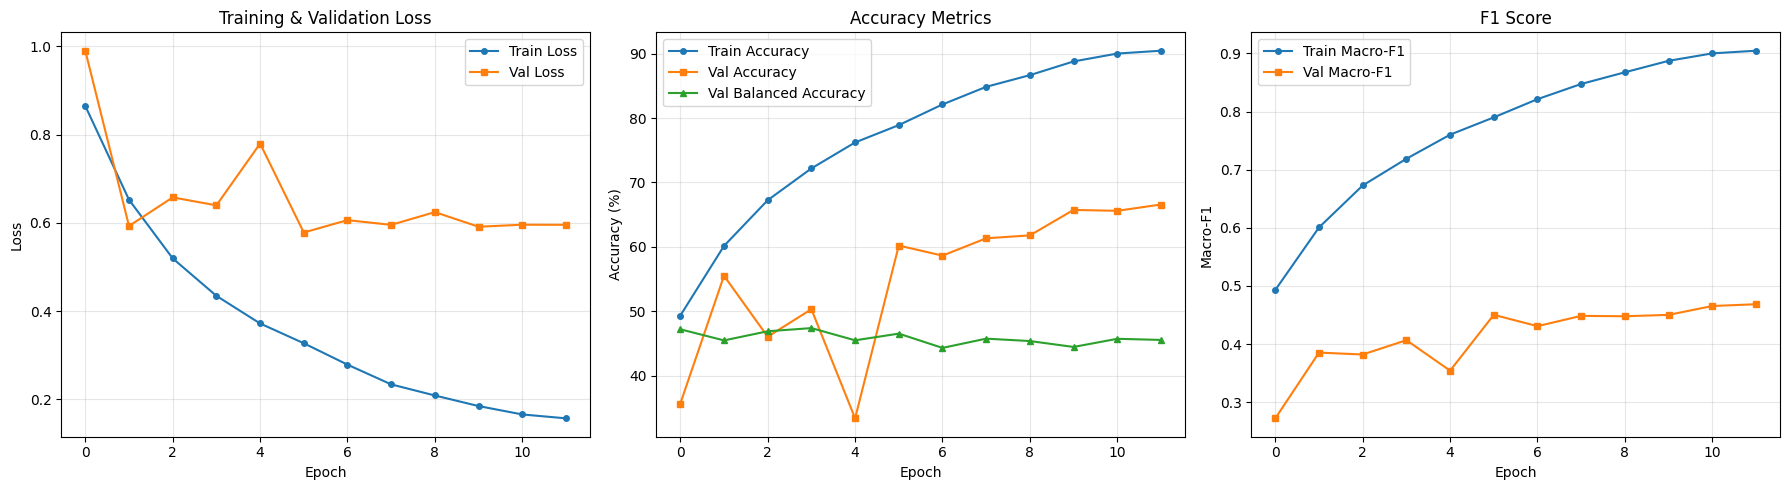

In [150]:
# plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x * 100 for x in history['train_acc']], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot([x * 100 for x in history['val_acc']], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot([x * 100 for x in history['val_bal_acc']], label='Val Balanced Accuracy', marker='^', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train Macro-F1', marker='o', markersize=4)
axes[2].plot(history['val_f1'], label='Val Macro-F1', marker='s', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs/training_curves_distilled_deit.png', dpi=150)
plt.show()

In [ ]:
from collections import Counter
import os

print("Train labels:", Counter(train_dataset.labels))
print("Val labels:  ", Counter(val_dataset.labels))
print("Test labels: ", Counter(test_dataset.labels))

print("\nCheckpoint exists?")
print("Without distillation:", os.path.exists("SplitDATA/checkpoints/best_deit_without_distillation.pth"))
print("With distillation:   ", os.path.exists("SplitDATA/checkpoints/best_distilled_deit_model.pth"))
print("Teacher:             ", os.path.exists("SplitDATA/checkpoints/teacher_regnety160_best.pth"))

Train labels: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Val labels:   Counter({0: 5165, 2: 1050, 1: 495, 3: 178, 4: 138})
Test labels:  Counter({0: 5154, 2: 1058, 1: 493, 3: 172, 4: 149})

Checkpoint exists?
Without distillation: True
With distillation:    True
Teacher:              True


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

os.makedirs("SplitDATA/logs", exist_ok=True)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs


def evaluate_and_save_test_results(
    model,
    test_loader,
    model_name,
    checkpoint_path,
    save_path,
    is_distilled=False
):
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    test_preds = []
    test_labels = []
    test_probs = []

    print(f"\nTesting: {model_name}")

    with torch.no_grad():

        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)
            preds = final_logits.argmax(dim=1)

            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_probs = np.array(test_probs)
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)

    cm = confusion_matrix(test_labels, test_preds)

    test_acc = accuracy_score(test_labels, test_preds)
    test_bal_acc = balanced_accuracy_score(test_labels, test_preds)
    macro_precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_recall = recall_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
    mcc = matthews_corrcoef(test_labels, test_preds)

    try:
        multiclass_auc = roc_auc_score(
            test_labels,
            test_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        multiclass_auc = None

    report = classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    result_text = (
        f"====================================================\n"
        f"TEST RESULTS - {model_name}\n"
        f"====================================================\n\n"
        f"Checkpoint                : {checkpoint_path}\n\n"
        f"Accuracy                  : {test_acc:.4f}\n"
        f"Balanced Accuracy         : {test_bal_acc:.4f}\n"
        f"Macro Precision           : {macro_precision:.4f}\n"
        f"Macro Recall              : {macro_recall:.4f}\n"
        f"Macro F1                  : {macro_f1:.4f}\n"
        f"Weighted F1               : {weighted_f1:.4f}\n"
        f"Quadratic Weighted Kappa  : {qwk:.4f}\n"
        f"Matthews Corrcoef         : {mcc:.4f}\n"
        f"Macro ROC-AUC OvR         : {multiclass_auc if multiclass_auc is not None else 'Not available'}\n\n"
        f"Classification Report:\n"
        f"{report}\n\n"
        f"Confusion Matrix:\n"
        f"{cm}\n\n"
        f"Class-wise Sensitivity / Specificity:\n"
    )

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        result_text += (
            f"{class_name:15s} | "
            f"Sensitivity: {sensitivity:.4f} | "
            f"Specificity: {specificity:.4f}\n"
        )

    print(result_text)

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"\nSaved test results to: {save_path}")

    return {
        "accuracy": test_acc,
        "balanced_accuracy": test_bal_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "qwk": qwk,
        "mcc": mcc,
        "auc": multiclass_auc,
        "cm": cm,
        "preds": test_preds,
        "labels": test_labels,
        "probs": test_probs,
    }



baseline_test_model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=False,
    num_classes=5
).to(device)

baseline_results = evaluate_and_save_test_results(
    model=baseline_test_model,
    test_loader=test_loader,
    model_name="DeiT WITHOUT Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_deit_without_distillation.pth",
    save_path="SplitDATA/logs/test_results_deit_without_distillation.txt",
    is_distilled=False
)


distilled_test_model = timm.create_model(
    "deit_small_distilled_patch16_224",
    pretrained=False,
    num_classes=5,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

distilled_results = evaluate_and_save_test_results(
    model=distilled_test_model,
    test_loader=test_loader,
    model_name="DeiT WITH Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_distilled_deit_model.pth",
    save_path="SplitDATA/logs/test_results_deit_with_distillation.txt",
    is_distilled=True
)



comparison_path = "SplitDATA/logs/test_comparison_summary_argmax.txt"
comparison_text = (
    "====================================================\n"
    "FINAL TEST COMPARISON\n"
    "====================================================\n\n"

    "1. DeiT WITHOUT Distillation\n"

    f"Argmax QWK               : {baseline_results['qwk']:.4f}\n"
    f"Tuned QWK                : {baseline_threshold_results['test_qwk']:.4f}\n"

    f"Macro F1                 : {baseline_results['macro_f1']:.4f}\n"
    f"Accuracy                 : {baseline_results['accuracy']:.4f}\n"
    f"Balanced Accuracy        : {baseline_results['balanced_accuracy']:.4f}\n\n"

    "2. DeiT WITH Distillation\n"

    f"Argmax QWK               : {distilled_results['qwk']:.4f}\n"
    f"Tuned QWK                : {distilled_threshold_results['test_qwk']:.4f}\n"

    f"Macro F1                 : {distilled_results['macro_f1']:.4f}\n"
    f"Accuracy                 : {distilled_results['accuracy']:.4f}\n"
    f"Balanced Accuracy        : {distilled_results['balanced_accuracy']:.4f}\n\n"
)




print(comparison_text)

with open(comparison_path, "w") as f:
    f.write(comparison_text)

print(f"Saved ARGMAX comparison summary to: {comparison_path}")


/tmp/ipykernel_617293/1400589135.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITHOUT Distillation


Testing DeiT WITHOUT Distillation: 100%|██████████| 440/440 [00:11<00:00, 36.83it/s]


TEST RESULTS - DeiT WITHOUT Distillation

Checkpoint                : SplitDATA/checkpoints/best_deit_without_distillation.pth

Accuracy                  : 0.7196
Balanced Accuracy         : 0.4234
Macro Precision           : 0.5081
Macro Recall              : 0.4234
Macro F1                  : 0.4492
Weighted F1               : 0.7146
Quadratic Weighted Kappa  : 0.5716
Matthews Corrcoef         : 0.3405
Macro ROC-AUC OvR         : 0.7267943357795987

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8405    0.8498    0.8452      5154
         Mild     0.1108    0.0892    0.0989       493
     Moderate     0.4235    0.4972    0.4574      1058
       Severe     0.4928    0.1977    0.2822       172
Proliferative     0.6729    0.4832    0.5625       149

     accuracy                         0.7196      7026
    macro avg     0.5081    0.4234    0.4492      7026
 weighted avg     0.7145    0.7196    0.7146      7026


Confusion Matrix:
[[43

/tmp/ipykernel_617293/1400589135.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITH Distillation


Testing DeiT WITH Distillation: 100%|██████████| 440/440 [00:11<00:00, 36.72it/s]

TEST RESULTS - DeiT WITH Distillation

Checkpoint                : SplitDATA/checkpoints/best_distilled_deit_model.pth

Accuracy                  : 0.6671
Balanced Accuracy         : 0.4475
Macro Precision           : 0.4965
Macro Recall              : 0.4475
Macro F1                  : 0.4619
Weighted F1               : 0.6891
Quadratic Weighted Kappa  : 0.5631
Matthews Corrcoef         : 0.3109
Macro ROC-AUC OvR         : 0.7440453721346517

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8507    0.7631    0.8045      5154
         Mild     0.1024    0.1846    0.1317       493
     Moderate     0.4174    0.5113    0.4596      1058
       Severe     0.4245    0.2616    0.3237       172
Proliferative     0.6875    0.5168    0.5900       149

     accuracy                         0.6671      7026
    macro avg     0.4965    0.4475    0.4619      7026
 weighted avg     0.7191    0.6671    0.6891      7026


Confusion Matrix:
[[3933  694 

In [ ]:

from scipy.optimize import differential_evolution
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, balanced_accuracy_score
import numpy as np
import torch.nn.functional as F
import os

os.makedirs("SplitDATA/logs", exist_ok=True)

def apply_thresholds(scores, thresholds):
    thresholds = np.sort(thresholds)

    preds = np.zeros_like(scores, dtype=int)

    for i, threshold in enumerate(thresholds):
        preds[scores > threshold] = i + 1

    return preds


def get_probs_and_labels(model, loader, is_distilled=False):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader, desc="Collecting probabilities"):

            images = images.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


def optimize_thresholds_for_qwk(val_scores, val_labels):

    def objective(thresholds):
        thresholds = np.sort(thresholds)
        preds = apply_thresholds(val_scores, thresholds)

        qwk = cohen_kappa_score(
            val_labels,
            preds,
            weights="quadratic"
        )

        return -qwk

    bounds = [
        (val_scores.min(), val_scores.max()),
        (val_scores.min(), val_scores.max()),
        (val_scores.min(), val_scores.max()),
        (val_scores.min(), val_scores.max())
    ]

    result = differential_evolution(
        objective,
        bounds,
        seed=SEED,
        maxiter=100,
        popsize=15,
        tol=1e-6,
        polish=True
    )

    best_thresholds = np.sort(result.x)
    best_val_qwk = -result.fun

    return best_thresholds, best_val_qwk


def tune_and_apply_thresholds(model, model_name, is_distilled=False):

    print(f"\nThreshold tuning for: {model_name}")


    val_probs, val_labels = get_probs_and_labels(
        model,
        val_loader,
        is_distilled=is_distilled
    )

    val_scores = val_probs @ np.arange(5)

    best_thresholds, val_qwk_tuned = optimize_thresholds_for_qwk(
        val_scores,
        val_labels
    )

    val_preds_tuned = apply_thresholds(
        val_scores,
        best_thresholds
    )

    val_f1_tuned = f1_score(
        val_labels,
        val_preds_tuned,
        average="macro",
        zero_division=0
    )

    val_acc_tuned = accuracy_score(
        val_labels,
        val_preds_tuned
    )

    val_bal_acc_tuned = balanced_accuracy_score(
        val_labels,
        val_preds_tuned
    )


    test_probs, test_labels = get_probs_and_labels(
        model,
        test_loader,
        is_distilled=is_distilled
    )

    test_scores = test_probs @ np.arange(5)

    test_preds_tuned = apply_thresholds(
        test_scores,
        best_thresholds
    )

    test_qwk_tuned = cohen_kappa_score(
        test_labels,
        test_preds_tuned,
        weights="quadratic"
    )

    test_f1_tuned = f1_score(
        test_labels,
        test_preds_tuned,
        average="macro",
        zero_division=0
    )

    test_acc_tuned = accuracy_score(
        test_labels,
        test_preds_tuned
    )

    test_bal_acc_tuned = balanced_accuracy_score(
        test_labels,
        test_preds_tuned
    )

    result_text = (
        f"\n====================================================\n"
        f"THRESHOLD TUNING RESULTS - {model_name}\n"
        f"====================================================\n"
        f"Best thresholds             : {best_thresholds}\n\n"
        f"Tuned Validation QWK        : {val_qwk_tuned:.4f}\n"
        f"Tuned Validation Macro F1   : {val_f1_tuned:.4f}\n"
        f"Tuned Validation Accuracy   : {val_acc_tuned:.4f}\n"
        f"Tuned Validation Bal Acc    : {val_bal_acc_tuned:.4f}\n\n"
        f"Tuned Test QWK              : {test_qwk_tuned:.4f}\n"
        f"Tuned Test Macro F1         : {test_f1_tuned:.4f}\n"
        f"Tuned Test Accuracy         : {test_acc_tuned:.4f}\n"
        f"Tuned Test Bal Accuracy     : {test_bal_acc_tuned:.4f}\n"
    )

    print(result_text)

    save_path = (
        "SplitDATA/logs/threshold_tuning_"
        + model_name.replace(" ", "_").replace("-", "_").lower()
        + ".txt"
    )

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved threshold tuning results to: {save_path}")

    return {
        "thresholds": best_thresholds,

        "val_qwk": val_qwk_tuned,
        "val_macro_f1": val_f1_tuned,
        "val_accuracy": val_acc_tuned,
        "val_balanced_accuracy": val_bal_acc_tuned,

        "test_qwk": test_qwk_tuned,
        "test_macro_f1": test_f1_tuned,
        "test_accuracy": test_acc_tuned,
        "test_balanced_accuracy": test_bal_acc_tuned,

        "test_preds": test_preds_tuned,
        "test_labels": test_labels,
        "test_probs": test_probs
    }


baseline_threshold_results = tune_and_apply_thresholds(
    baseline_test_model,
    "DeiT WITHOUT Distillation",
    is_distilled=False
)


distilled_threshold_results = tune_and_apply_thresholds(
    distilled_test_model,
    "DeiT WITH Distillation",
    is_distilled=True
)


Threshold tuning for: DeiT WITHOUT Distillation



THRESHOLD TUNING RESULTS - DeiT WITHOUT Distillation
Best thresholds             : [1.04325933 1.61589889 1.91262579 2.13704018]

Tuned Validation QWK        : 0.6409
Tuned Validation Macro F1   : 0.3741
Tuned Validation Accuracy   : 0.7109
Tuned Validation Bal Acc    : 0.4114

Tuned Test QWK              : 0.6492
Tuned Test Macro F1         : 0.3868
Tuned Test Accuracy         : 0.7114
Tuned Test Bal Accuracy     : 0.4258

Saved threshold tuning results to: SplitDATA/logs/threshold_tuning_deit_without_distillation.txt

Threshold tuning for: DeiT WITH Distillation



THRESHOLD TUNING RESULTS - DeiT WITH Distillation
Best thresholds             : [0.95862432 1.522749   1.92242991 2.50014122]

Tuned Validation QWK        : 0.6374
Tuned Validation Macro F1   : 0.3890
Tuned Validation Accuracy   : 0.6874
Tuned Validation Bal Acc    : 0.4146

Tuned Test QWK              : 0.6571
Tuned Test Macro F1         : 0.4098
Tuned Test Accuracy         : 0.6943
Tuned Test Bal Accuracy     : 0.4394

Saved threshold tuning results to: SplitDATA/logs/threshold_tuning_deit_with_distillation.txt


In [ ]:

import pandas as pd
from IPython.display import display

threshold_comparison_df = pd.DataFrame({
    "Metric": [
        "Tuned Test QWK",
        "Tuned Test Macro F1",
        "Tuned Test Accuracy",
        "Tuned Test Balanced Accuracy"
    ],
    "DeiT WITHOUT Distillation": [
        baseline_threshold_results["test_qwk"],
        baseline_threshold_results["test_macro_f1"],
        baseline_threshold_results["test_accuracy"],
        baseline_threshold_results["test_balanced_accuracy"]
    ],
    "DeiT WITH Distillation": [
        distilled_threshold_results["test_qwk"],
        distilled_threshold_results["test_macro_f1"],
        distilled_threshold_results["test_accuracy"],
        distilled_threshold_results["test_balanced_accuracy"]
    ]
})

threshold_comparison_df.iloc[:, 1:] = threshold_comparison_df.iloc[:, 1:].round(4)

display(
    threshold_comparison_df.style.set_caption(
        "Threshold-Tuned Test Results"
    )
)

threshold_comparison_df.to_csv(
    "SplitDATA/logs/threshold_tuned_comparison_table.csv",
    index=False
)

,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Tuned Test QWK,0.649200,0.657100
1,Tuned Test Macro F1,0.386800,0.409800
2,Tuned Test Accuracy,0.711400,0.694300
3,Tuned Test Balanced Accuracy,0.425800,0.439400


In [ ]:
from collections import Counter

print("WITHOUT DISTILLATION")
print("True labels:")
print(Counter(baseline_results["labels"]))

print("\nPredicted labels:")
print(Counter(baseline_results["preds"]))

print("\nWITH DISTILLATION")
print("True labels:")
print(Counter(distilled_results["labels"]))

print("\nPredicted labels:")
print(Counter(distilled_results["preds"]))

WITHOUT DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 5211, np.int64(2): 1242, np.int64(1): 397, np.int64(4): 107, np.int64(3): 69})


WITH DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 4623, np.int64(2): 1296, np.int64(1): 889, np.int64(4): 112, np.int64(3): 106})


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("SplitDATA/logs/confusion_matrices", exist_ok=True)

def save_confusion_matrix(cm, class_names, title, save_path):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.close()

    print(f"Saved confusion matrix: {save_path}")


save_confusion_matrix(
    baseline_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITHOUT Distillation",
    "SplitDATA/logs/confusion_matrices/cm_without_distillation.png"
)


save_confusion_matrix(
    distilled_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITH Distillation",
    "SplitDATA/logs/confusion_matrices/cm_with_distillation.png"
)

Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_without_distillation.png
Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_with_distillation.png


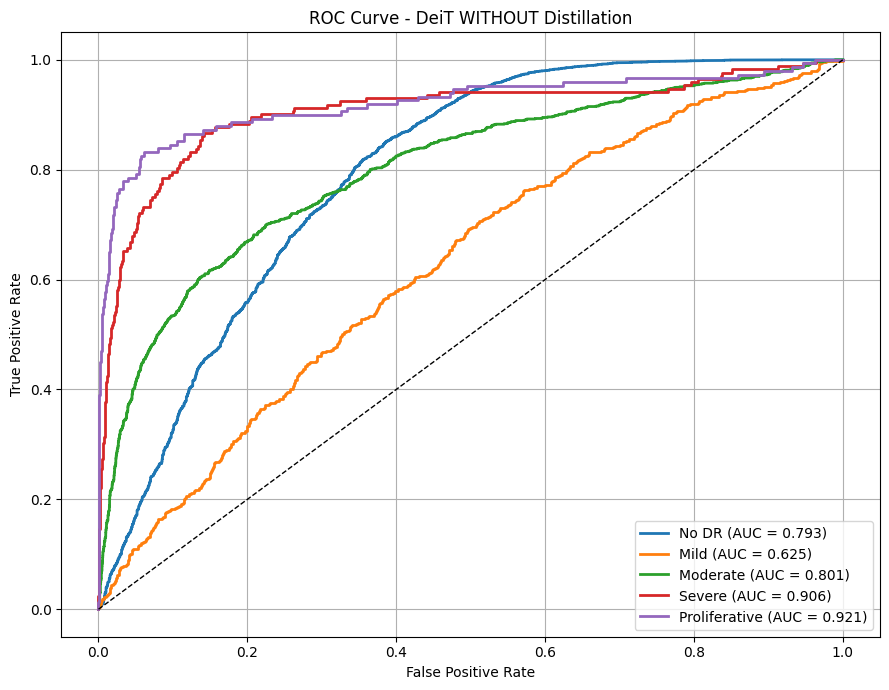

Saved ROC curve: SplitDATA/logs/roc_curves/roc_without_distillation.png


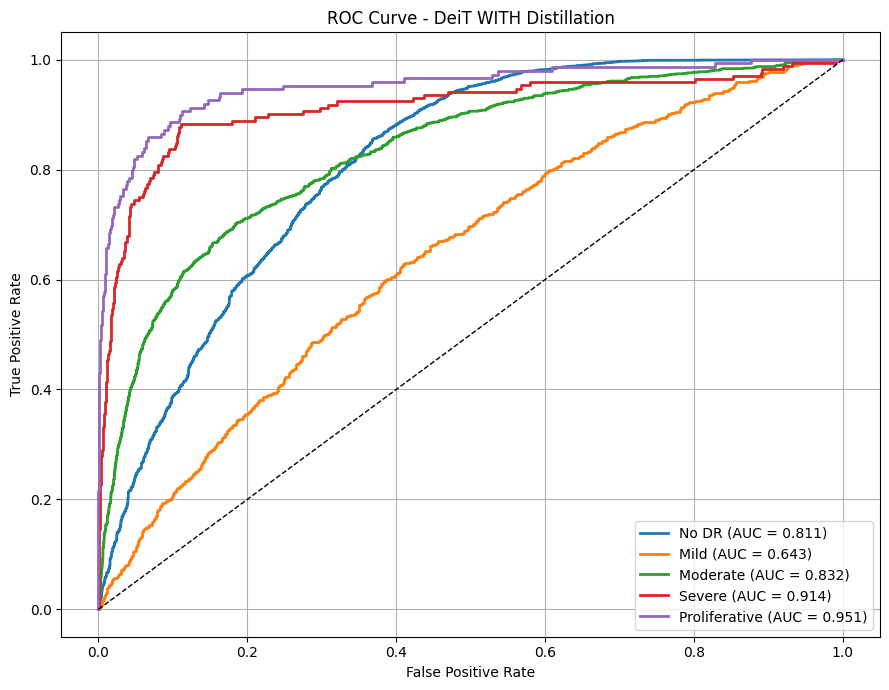

Saved ROC curve: SplitDATA/logs/roc_curves/roc_with_distillation.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

os.makedirs("SplitDATA/logs/roc_curves", exist_ok=True)

def plot_multiclass_roc(
    test_labels,
    test_probs,
    class_names,
    title,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0,1,2,3,4]
    )

    n_classes = y_true_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(9, 7))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
        )

    plt.plot([0,1], [0,1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.show()

    print(f"Saved ROC curve: {save_path}")


plot_multiclass_roc(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_without_distillation.png"
)



plot_multiclass_roc(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITH Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_with_distillation.png"
)

In [ ]:
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize
from IPython.display import display
import pandas as pd
import numpy as np
import os

os.makedirs("SplitDATA/logs", exist_ok=True)


def compute_map(
    test_labels,
    test_probs,
    class_names,
    model_name,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0, 1, 2, 3, 4]
    )

    n_classes = y_true_bin.shape[1]

    ap_per_class = []

    result_text = (
        f"====================================================\n"
        f"mAP RESULTS - {model_name}\n"
        f"====================================================\n\n"
    )

    print(f"\n{model_name}")

    for i in range(n_classes):

        ap = average_precision_score(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        ap_per_class.append(ap)

        result_text += f"{class_names[i]} AP: {ap:.4f}\n"

        print(f"{class_names[i]} AP: {ap:.4f}")

    mAP = np.mean(ap_per_class)

    result_text += f"\nmAP: {mAP:.4f}\n"

    print(f"\nmAP: {mAP:.4f}")

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved mAP results to: {save_path}")

    return {
        "ap_per_class": ap_per_class,
        "mAP": mAP
    }



baseline_map_results = compute_map(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    model_name="DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/map_without_distillation.txt"
)


distilled_map_results = compute_map(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    model_name="DeiT WITH Distillation",
    save_path="SplitDATA/logs/map_with_distillation.txt"
)



map_summary_path = "SplitDATA/logs/map_comparison_summary.txt"

summary_text = (
    "====================================================\n"
    "FINAL mAP COMPARISON\n"
    "====================================================\n\n"
    "DeiT WITHOUT Distillation\n"
    f"mAP: {baseline_map_results['mAP']:.4f}\n\n"
    "DeiT WITH Distillation\n"
    f"mAP: {distilled_map_results['mAP']:.4f}\n"
)

print(summary_text)

with open(map_summary_path, "w") as f:
    f.write(summary_text)

print(f"Saved mAP comparison summary to: {map_summary_path}")

comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "QWK",
        "MCC",
        "ROC-AUC OvR",
        "mAP"
    ],

    "DeiT WITHOUT Distillation": [
        baseline_results["accuracy"],
        baseline_results["balanced_accuracy"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"],
        baseline_results["weighted_f1"],
        baseline_results["qwk"],
        baseline_results["mcc"],
        baseline_results["auc"] if baseline_results["auc"] is not None else np.nan,
        baseline_map_results["mAP"]
    ],

    "DeiT WITH Distillation": [
        distilled_results["accuracy"],
        distilled_results["balanced_accuracy"],
        distilled_results["macro_precision"],
        distilled_results["macro_recall"],
        distilled_results["macro_f1"],
        distilled_results["weighted_f1"],
        distilled_results["qwk"],
        distilled_results["mcc"],
        distilled_results["auc"] if distilled_results["auc"] is not None else np.nan,
        distilled_map_results["mAP"]
    ]
    
    
})

comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

print("\nFINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")

display(
    comparison_df.style
    .set_caption("Original Argmax Results: DeiT Without vs With Distillation")
    .set_properties(**{
        "text-align": "center"
    })
)


table_csv_path = "SplitDATA/logs/final_comparison_table_argmax.csv"
table_txt_path = "SplitDATA/logs/final_comparison_table_argmax.txt"

comparison_df.to_csv(table_csv_path, index=False)

with open(table_txt_path, "w") as f:
    f.write("FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")
    f.write("====================================================\n\n")
    f.write(comparison_df.to_string(index=False))

print(f"Saved argmax comparison CSV to: {table_csv_path}")
print(f"Saved argmax comparison TXT to: {table_txt_path}")


DeiT WITHOUT Distillation
No DR AP: 0.8803
Mild AP: 0.0869
Moderate AP: 0.4224
Severe AP: 0.2533
Proliferative AP: 0.4928

mAP: 0.4271
Saved mAP results to: SplitDATA/logs/map_without_distillation.txt

DeiT WITH Distillation
No DR AP: 0.8765
Mild AP: 0.0880
Moderate AP: 0.4307
Severe AP: 0.2645
Proliferative AP: 0.5585

mAP: 0.4437
Saved mAP results to: SplitDATA/logs/map_with_distillation.txt
FINAL mAP COMPARISON

DeiT WITHOUT Distillation
mAP: 0.4271

DeiT WITH Distillation
mAP: 0.4437

Saved mAP comparison summary to: SplitDATA/logs/map_comparison_summary.txt

FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS



,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Accuracy,0.719600,0.667100
1,Balanced Accuracy,0.423400,0.447500
2,Macro Precision,0.508100,0.496500
3,Macro Recall,0.423400,0.447500
4,Macro F1,0.449200,0.461900
5,Weighted F1,0.714600,0.689100
6,QWK,0.571600,0.563100
7,MCC,0.340500,0.310900
8,ROC-AUC OvR,0.726800,0.744000
9,mAP,0.427100,0.443700


Saved argmax comparison CSV to: SplitDATA/logs/final_comparison_table_argmax.csv
Saved argmax comparison TXT to: SplitDATA/logs/final_comparison_table_argmax.txt
